In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import os


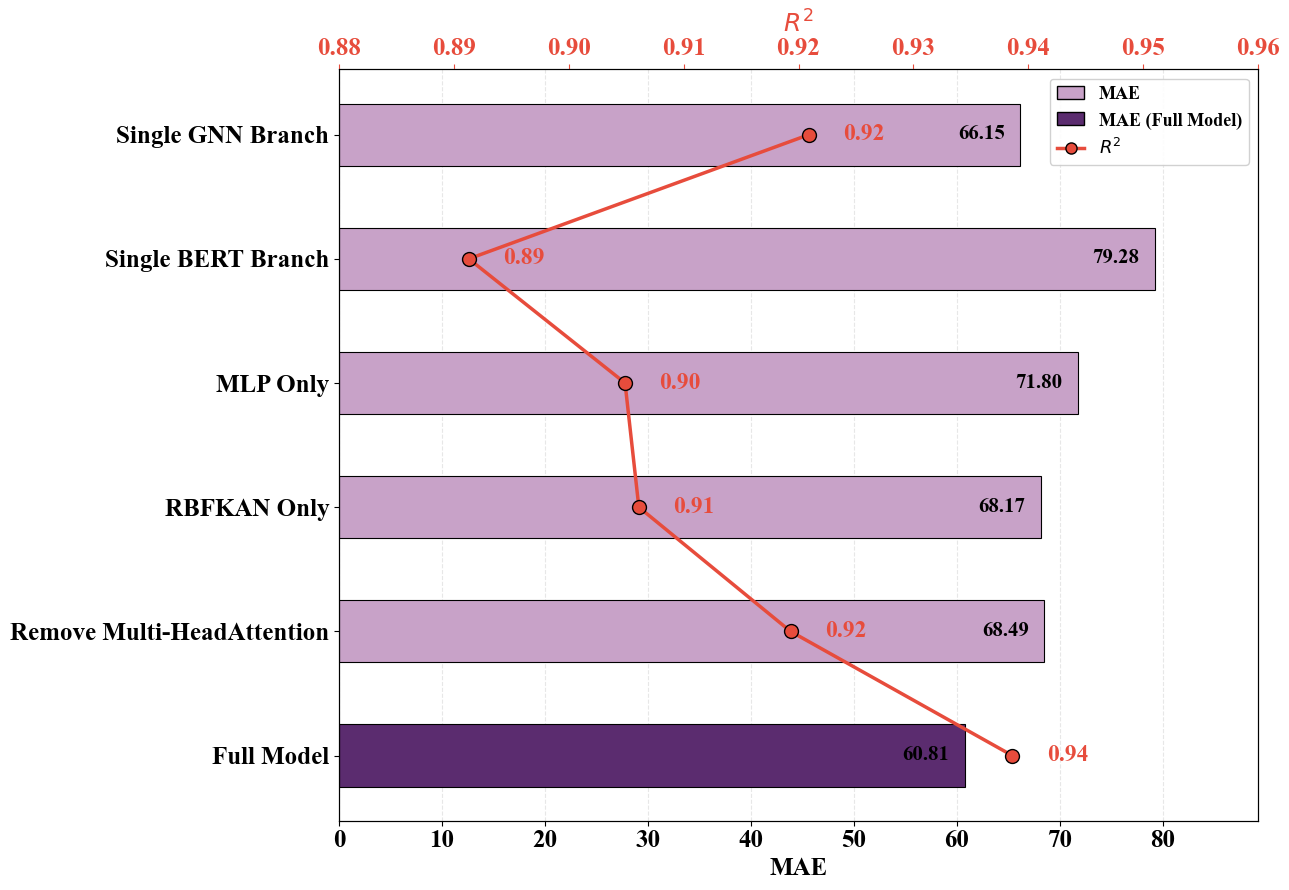

Saved: 图表/ablation_study_mae.png
Done!


In [3]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False

# Data
models = [
    'Single GNN Branch',
    'Single BERT Branch',
    'MLP Only',
    'RBFKAN Only',
    'Remove Multi-HeadAttention',
    'Full Model'
]

MAE = [66.15, 79.28, 71.80, 68.17, 68.49, 60.81]
R2 = [0.9209, 0.8913, 0.9049, 0.9061, 0.9193, 0.9386]

output_dir = '图表'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

fig, ax1 = plt.subplots(figsize=(13, 9))

y = np.arange(len(models))
bar_height = 0.5

# Colors: last bar (Full Model) highlighted
colors = ['#C8A2C8', '#C8A2C8', '#C8A2C8', '#C8A2C8', '#C8A2C8', '#5B2C6F']

# Horizontal bars for MAE
bars = ax1.barh(y, MAE, height=bar_height, color=colors, edgecolor='black', linewidth=0.8, zorder=2)

# Add MAE value labels (black, bold)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width - 1.5, bar.get_y() + bar.get_height()/2.,
            f'{MAE[i]:.2f}', ha='right', va='center',
            fontsize=15, fontweight='bold', color='black')

ax1.set_xlabel('MAE', fontsize=18, fontweight='bold')
ax1.set_yticks(y)
ax1.set_yticklabels(models, fontsize=18, fontweight='bold')
ax1.tick_params(axis='x', labelsize=18)
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.set_xlim(0, max(MAE) + 10)
ax1.invert_yaxis()  # Full Model at bottom
ax1.grid(axis='x', alpha=0.3, linestyle='--', zorder=0)

# Second y-axis for R2 line
ax2 = ax1.twiny()
line = ax2.plot(R2, y, 'o-', color='#E74C3C', linewidth=2.5, markersize=10,
                markerfacecolor='#E74C3C', markeredgecolor='black', markeredgewidth=1,
                zorder=5, label='$R^2$')

# Add R2 value labels (black, bold)
for i in range(len(models)):
    ax2.text(R2[i] + 0.003, y[i], f'{R2[i]:.2f}',
            ha='left', va='center', fontsize=17, fontweight='bold', color='#E74C3C')

ax2.set_xlabel('$R^2$', fontsize=18, fontweight='bold', color='#E74C3C')
ax2.tick_params(axis='x', labelsize=18, colors='#E74C3C')
for label in ax2.get_xticklabels():
    label.set_fontweight('bold')
ax2.set_xlim(0.88, 0.96)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#C8A2C8', edgecolor='black', label='MAE'),
    Patch(facecolor='#5B2C6F', edgecolor='black', label='MAE (Full Model)'),
    Line2D([0], [0], color='#E74C3C', marker='o', linewidth=2.5, markersize=8,
           markerfacecolor='#E74C3C', markeredgecolor='black', label='$R^2$')
]
legend = ax1.legend(handles=legend_elements, loc='upper right', fontsize=13, framealpha=0.9, labelspacing=0.5, handlelength=1.5, borderpad=0.4)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
output_path = os.path.join(output_dir, 'ablation_study_mae.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")
plt.close()
print("Done!")


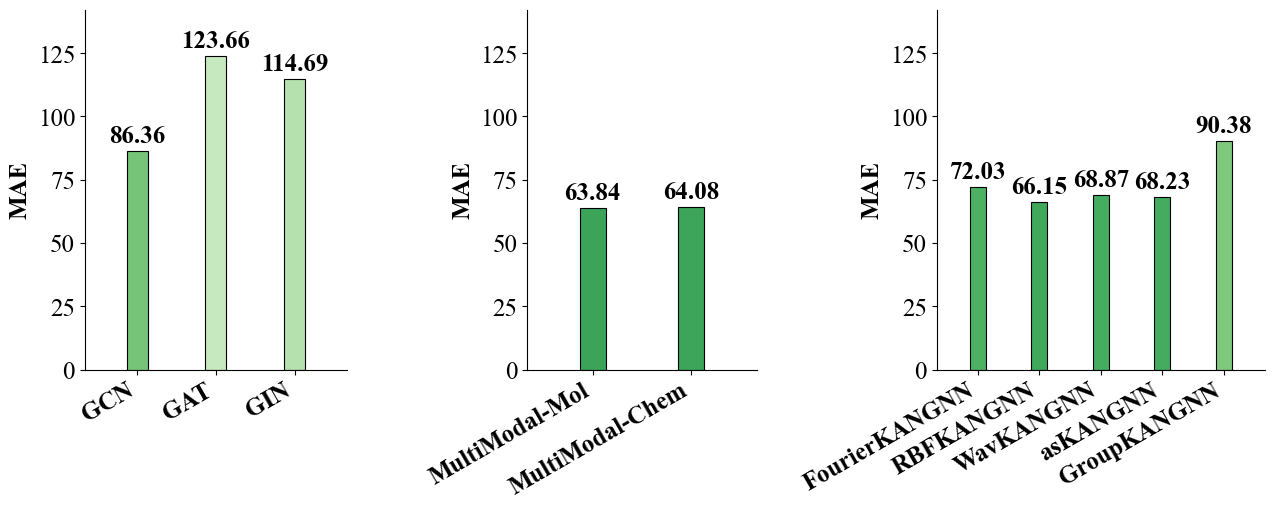

Saved to /Users/wangxujie/Desktop/GNN-Multi-v2-tenfold-ChemBERT2-copy/data/mae_comparison.png


In [5]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

# ====== 数据 ======
data1 = {
    'models': ['GCN', 'GAT', 'GIN'],
    'mae': [86.36, 123.66, 114.69],
}

data2 = {
    'models': ['MultiModal-Mol', 'MultiModal-Chem'],
    'mae': [63.84, 64.08],
}

data3 = {
    'models': ['FourierKANGNN', 'RBFKANGNN', 'WavKANGNN', 'asKANGNN', 'GroupKANGNN'],
    'mae': [72.03, 66.15, 68.87, 68.23, 90.38],
}

bar_width = 0.4
n_data = 3

# ====== 计算每个子图的宽度（进一步加宽，避免18号数字标签重叠） ======
widths = [(len(d['models']) + 5) * bar_width for d in [data1, data2, data3]]
total_width = sum(widths)
height = 5

fig = plt.figure(figsize=(total_width, height))

# ====== 手动创建每个子图，宽度不同 ======
norm_widths = [w / total_width for w in widths]

axes = []
left = 0.03
gap = 0.18
for i, nw in enumerate(norm_widths):
    ax = fig.add_axes([left, 0.18, nw * 0.82, 0.72])
    axes.append(ax)
    left += nw * 0.82 + gap

# ====== 绘制柱状图 ======
all_mae_list = data1['mae'] + data2['mae'] + data3['mae']
all_mae = np.array(all_mae_list)
y_max = all_mae.max() * 1.15

# 使用 Greens 色阶，全局共用一套深浅体系，MAE 越小颜色越深
# 限制色阶范围，避免过深和过浅
cmap = plt.colormaps['Greens']
norm_global = Normalize(vmin=all_mae.min(), vmax=all_mae.max())
vmin_cmap = 0.25
vmax_cmap = 0.65

def get_color(val):
    t = norm_global(val)
    cmap_val = vmax_cmap - t * (vmax_cmap - vmin_cmap)
    return cmap(cmap_val)

for idx, (ax, data) in enumerate(zip(axes, [data1, data2, data3])):
    models = data['models']
    mae_vals = np.array(data['mae'])
    n = len(models)

    colors = [get_color(v) for v in mae_vals]

    # 增大柱子间距，避免18号数字标签和x轴标签重叠
    x = np.arange(n) * 1.5
    bars = ax.bar(x, mae_vals, width=bar_width, color=colors, edgecolor='black', linewidth=0.8)

    # 增加 x 轴左右两端的留白，避免最左侧数字与 y 轴重合
    ax.set_xlim(-1.0, x.max() + 1.0)

    # 数值标签放在柱子上方居中
    for bar, val in zip(bars, mae_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=18, fontweight='bold',
                color='black')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=16, fontweight='bold')
    ax.set_ylim(0, y_max)
    ax.set_ylabel('MAE', fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

save_path = '/Users/wangxujie/Desktop/GNN-Multi-v2-tenfold-ChemBERT2-copy/data/mae_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {save_path}')
plt.close()
